In [242]:
import pandas as pd
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [243]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df = assign_class_type(df,df_class)

In [244]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32609 entries, 0 to 32608
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 32609 non-null  int64                         
 1   username           32609 non-null  str                           
 2   cycle_start        32609 non-null  datetime64[ns, Asia/Singapore]
 3   cycle_end          32609 non-null  datetime64[ns, Asia/Singapore]
 4   polling_at         32609 non-null  datetime64[ns, Asia/Singapore]
 5   booking_hour       513 non-null    datetime64[ns, Asia/Singapore]
 6   has_booking        32609 non-null  bool                          
 7   cycle_start_month  32609 non-null  int32                         
 8   cycle_start_day    32609 non-null  int32                         
 9   cycle_start_dow    32609 non-null  int32                         
 10  cycle_start_hour   32609 non-null  int32     

In [245]:
df.tail()

,id,username,cycle_start,cycle_end,polling_at,booking_hour,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
32604,32604,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 19:00:00+08:00,NaT,False,3,30,0,10,4,13,0,19,345.0,1,1
32605,32605,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 20:00:00+08:00,NaT,False,3,30,0,10,4,13,0,20,346.0,1,1
32606,32606,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 21:00:00+08:00,NaT,False,3,30,0,10,4,13,0,21,347.0,1,1
32607,32607,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 22:00:00+08:00,NaT,False,3,30,0,10,4,13,0,22,348.0,1,1
32608,32608,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 23:00:00+08:00,NaT,False,3,30,0,10,4,13,0,23,349.0,1,1


In [246]:
#df = df.loc[~(df["username"]=="anmol")]

In [247]:
counts = df["has_booking"].value_counts()
shares = df["has_booking"].value_counts(normalize=True)

tp = pd.concat([counts, shares], axis=1)
tp.columns = ["count", "share"]

In [248]:
tp

,count,share
has_booking,,
False,32096,0.984268
True,513,0.015732


In [249]:
def eda_label_rate(x):
    label_rate = (
        df.groupby(x)["has_booking"]
        .agg(share="mean", count="count")
        .reset_index()
    )
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Top: label rate with 95% CI
    sns.barplot(data=df, x=x, y="has_booking", ax=axes[0], errorbar=("ci", 95))
    axes[0].set_ylabel("P(has_booking)")

    # Bottom: exposure per category
    sns.barplot(data=label_rate, x=x, y="count", ax=axes[1], color="steelblue")
    axes[1].set_ylabel("n observations")

    plt.tight_layout()


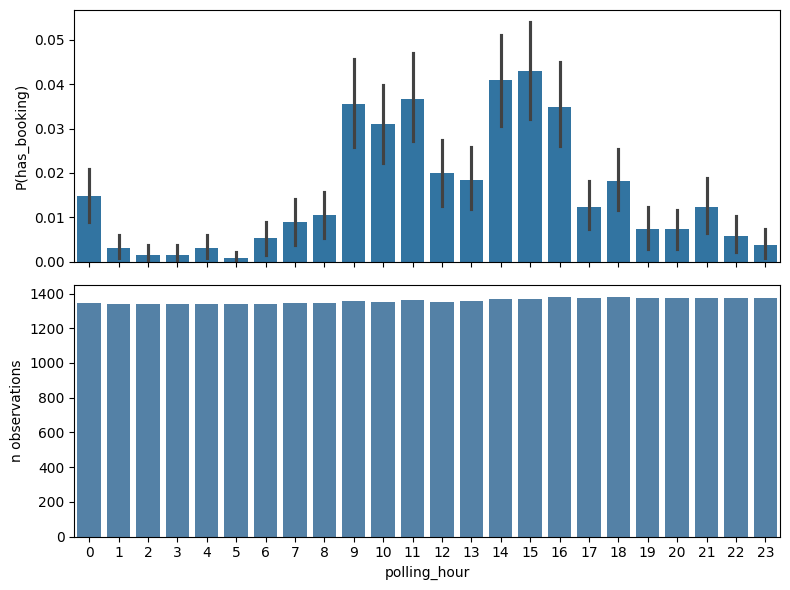

In [250]:
eda_label_rate("polling_hour")

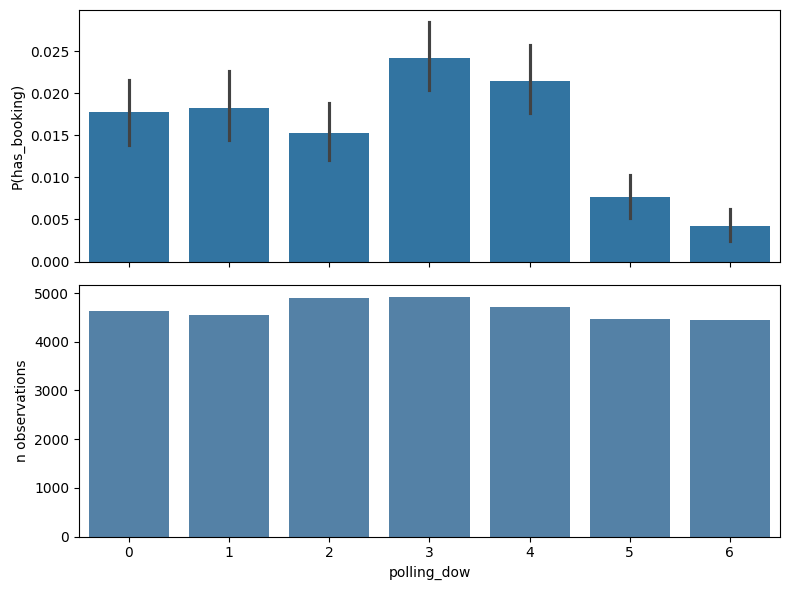

In [251]:
eda_label_rate("polling_dow")

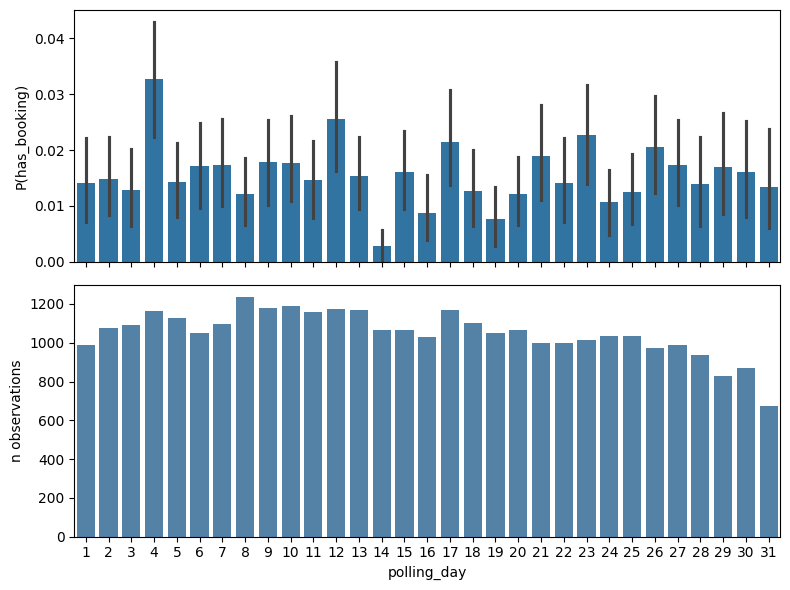

In [252]:
eda_label_rate("polling_day")

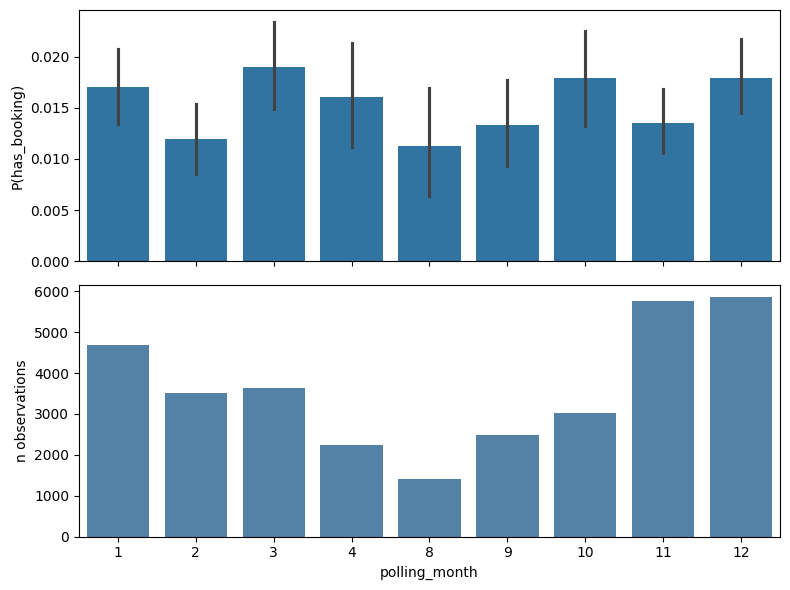

In [253]:
label_rate_by_polling_month = eda_label_rate("polling_month")

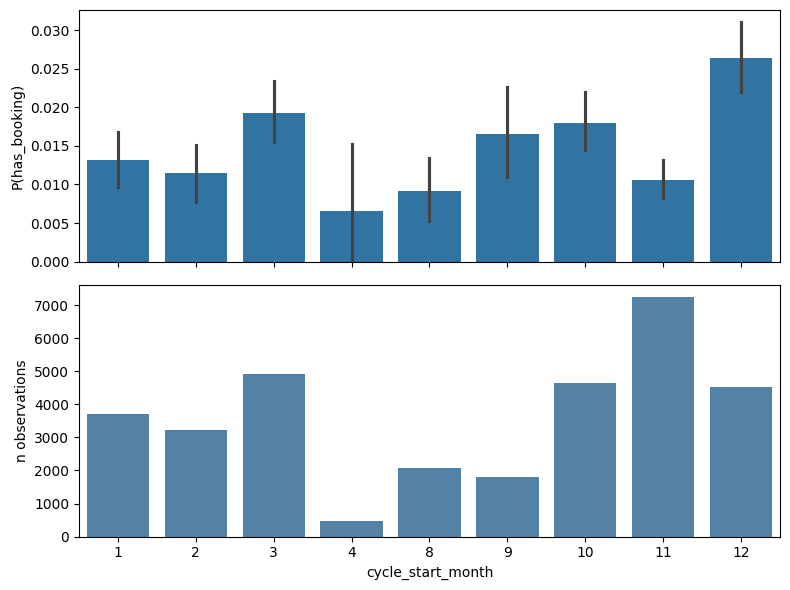

In [254]:
eda_label_rate("cycle_start_month")

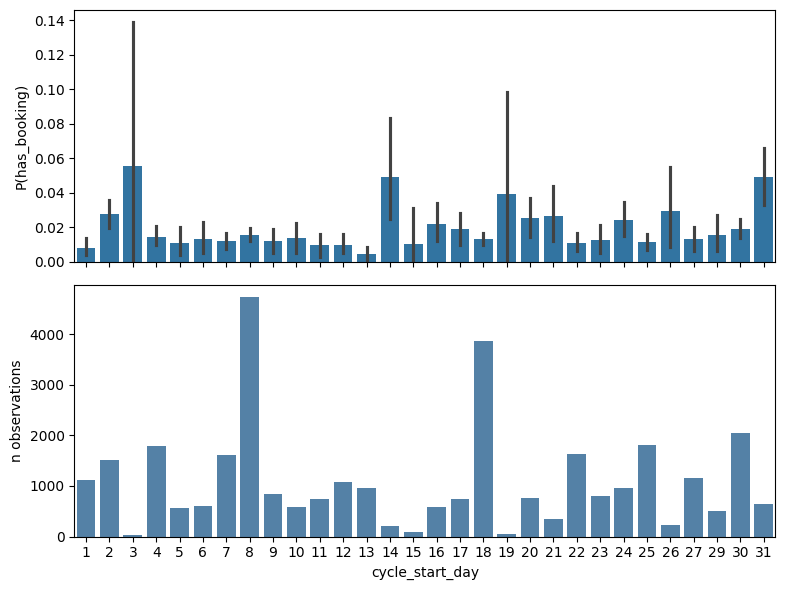

In [255]:
eda_label_rate("cycle_start_day")

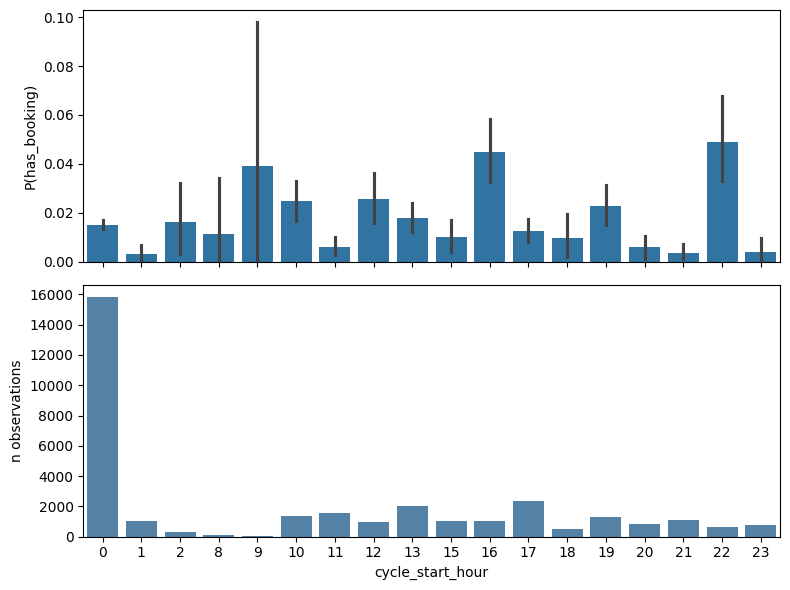

In [256]:
eda_label_rate("cycle_start_hour")

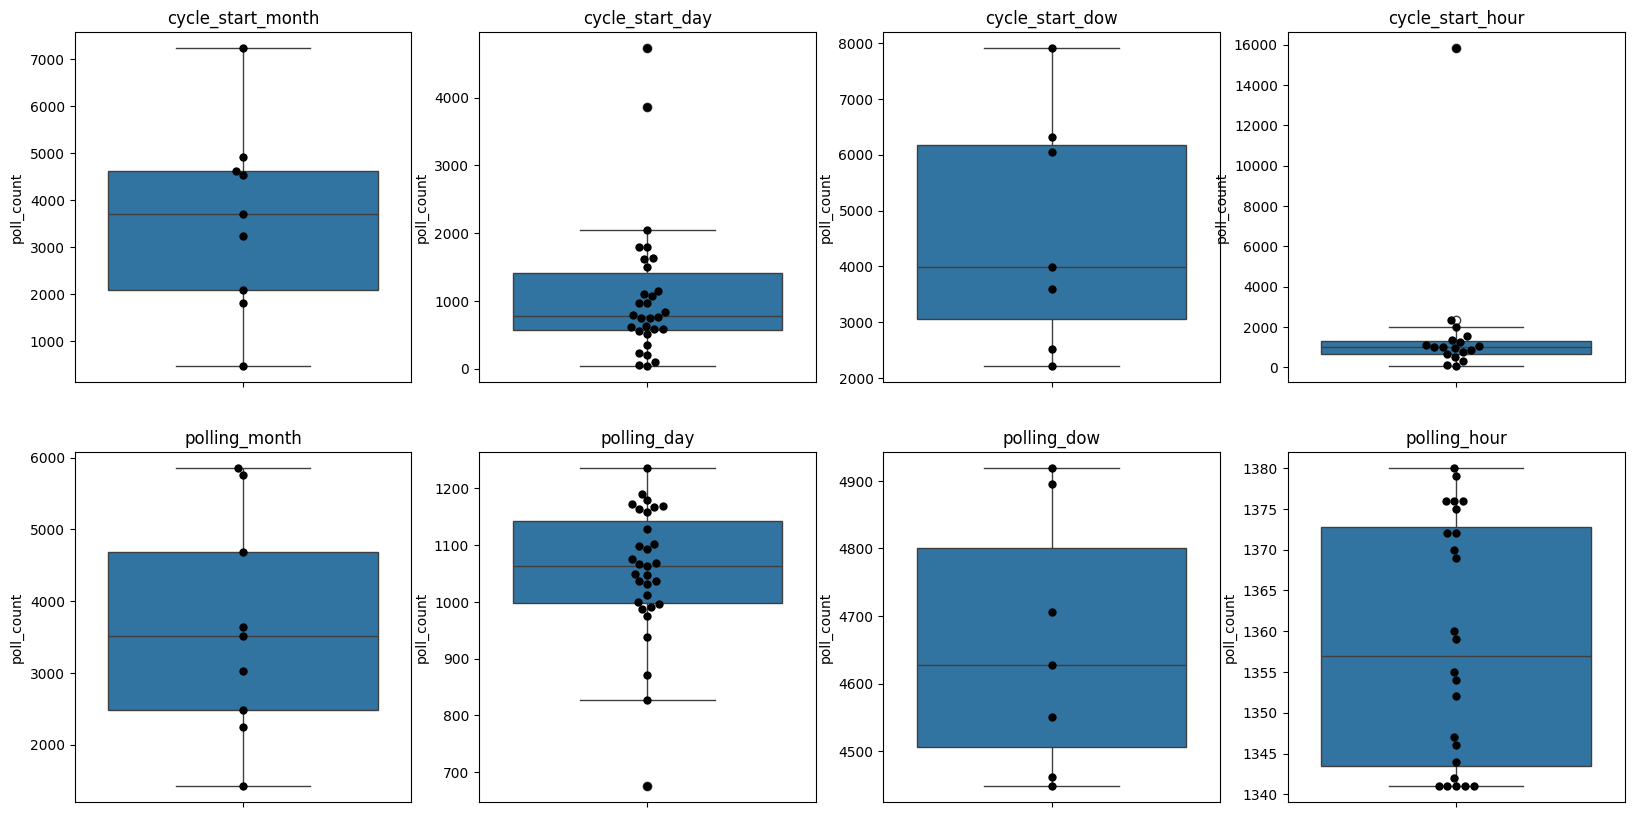

In [257]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

In [258]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramer_v_table():
    df = pd.DataFrame({
        "dof":[1,2,3,4,5],
        "small":[.10,.07,.06,.05,.05],
        "medium":[.30,.21,.17,.15,.13],
        "large":[.50,.35,.29,.25,.22]
    })
    return df

def corr_check_chi_v(x,y):
    exact_match = (df[x] == df[y]).mean()
    print(f"Exact match rate: {exact_match:.1%}")

    ct = pd.crosstab(df[x], df[y])
    chi2, p, dof, _ = chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"χ²={chi2:.1f}, p={p:.2e}, Cramér's V={cramers_v:.3f} dof={min_dim} \n")
    print(cramer_v_table())




In [259]:
corr_check_chi_v("cycle_start_month","polling_month")

Exact match rate: 70.1%
χ²=148575.1, p=0.00e+00, Cramér's V=0.755 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [260]:
corr_check_chi_v("cycle_start_day","polling_day")

Exact match rate: 6.6%
χ²=30642.5, p=0.00e+00, Cramér's V=0.180 dof=29 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [261]:
corr_check_chi_v("cycle_start_hour","polling_hour")

Exact match rate: 4.3%
χ²=25.3, p=1.00e+00, Cramér's V=0.007 dof=17 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [262]:

corr_check_chi_v("polling_month","polling_day")

Exact match rate: 3.8%
χ²=6421.5, p=0.00e+00, Cramér's V=0.157 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [263]:
corr_check_chi_v("polling_day","polling_dow")

Exact match rate: 0.0%
χ²=13574.7, p=0.00e+00, Cramér's V=0.263 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [264]:
corr_check_chi_v("polling_dow","polling_hour")

Exact match rate: 4.1%
χ²=3.6, p=1.00e+00, Cramér's V=0.004 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [265]:
corr_check_chi_v("polling_dow","has_booking")

Exact match rate: 14.2%
χ²=92.5, p=9.28e-18, Cramér's V=0.053 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [266]:

corr_check_chi_v("polling_hour","has_booking")

Exact match rate: 4.1%
χ²=385.8, p=1.51e-67, Cramér's V=0.109 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [267]:
df["username"].value_counts(normalize=True).sort_values(ascending=False)

username
kim        0.117176
jy         0.072649
flower     0.069551
anmol      0.063387
ryan       0.060321
anaya      0.053053
mya        0.050784
matt       0.048269
ali        0.047533
srpr       0.046214
faith      0.034990
tomato     0.033089
brendon    0.032016
joy        0.025821
jun        0.025760
apple      0.024134
poopie     0.023368
gohguan    0.021650
natar      0.016928
fir        0.015977
bw         0.014751
addity     0.014720
np         0.013033
bryan      0.010887
lucinda    0.009016
d          0.008096
aswath     0.006869
nur        0.006655
phuc       0.006409
carol      0.005888
sara       0.005489
pakning    0.004631
bhara      0.004416
isyaf      0.002239
ajithak    0.001564
max        0.001564
ranjith    0.001104
Name: proportion, dtype: float64

In [268]:
df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False)

username
anmol      109
jy          44
mya         39
poopie      35
jun         30
joy         27
kim         27
srpr        21
tomato      20
flower      18
faith       15
addity      15
apple       12
anaya        9
bryan        9
ryan         8
brendon      8
aswath       7
ali          6
nur          5
np           5
matt         5
carol        4
max          4
sara         4
phuc         3
bhara        3
fir          3
gohguan      3
lucinda      3
pakning      3
ajithak      2
isyaf        2
natar        2
d            1
bw           1
ranjith      1
Name: has_booking, dtype: int64

   username  has_booking
32     ryan         1967
33    anmol         2067
34   flower         2268
35       jy         2369
36      kim         3821


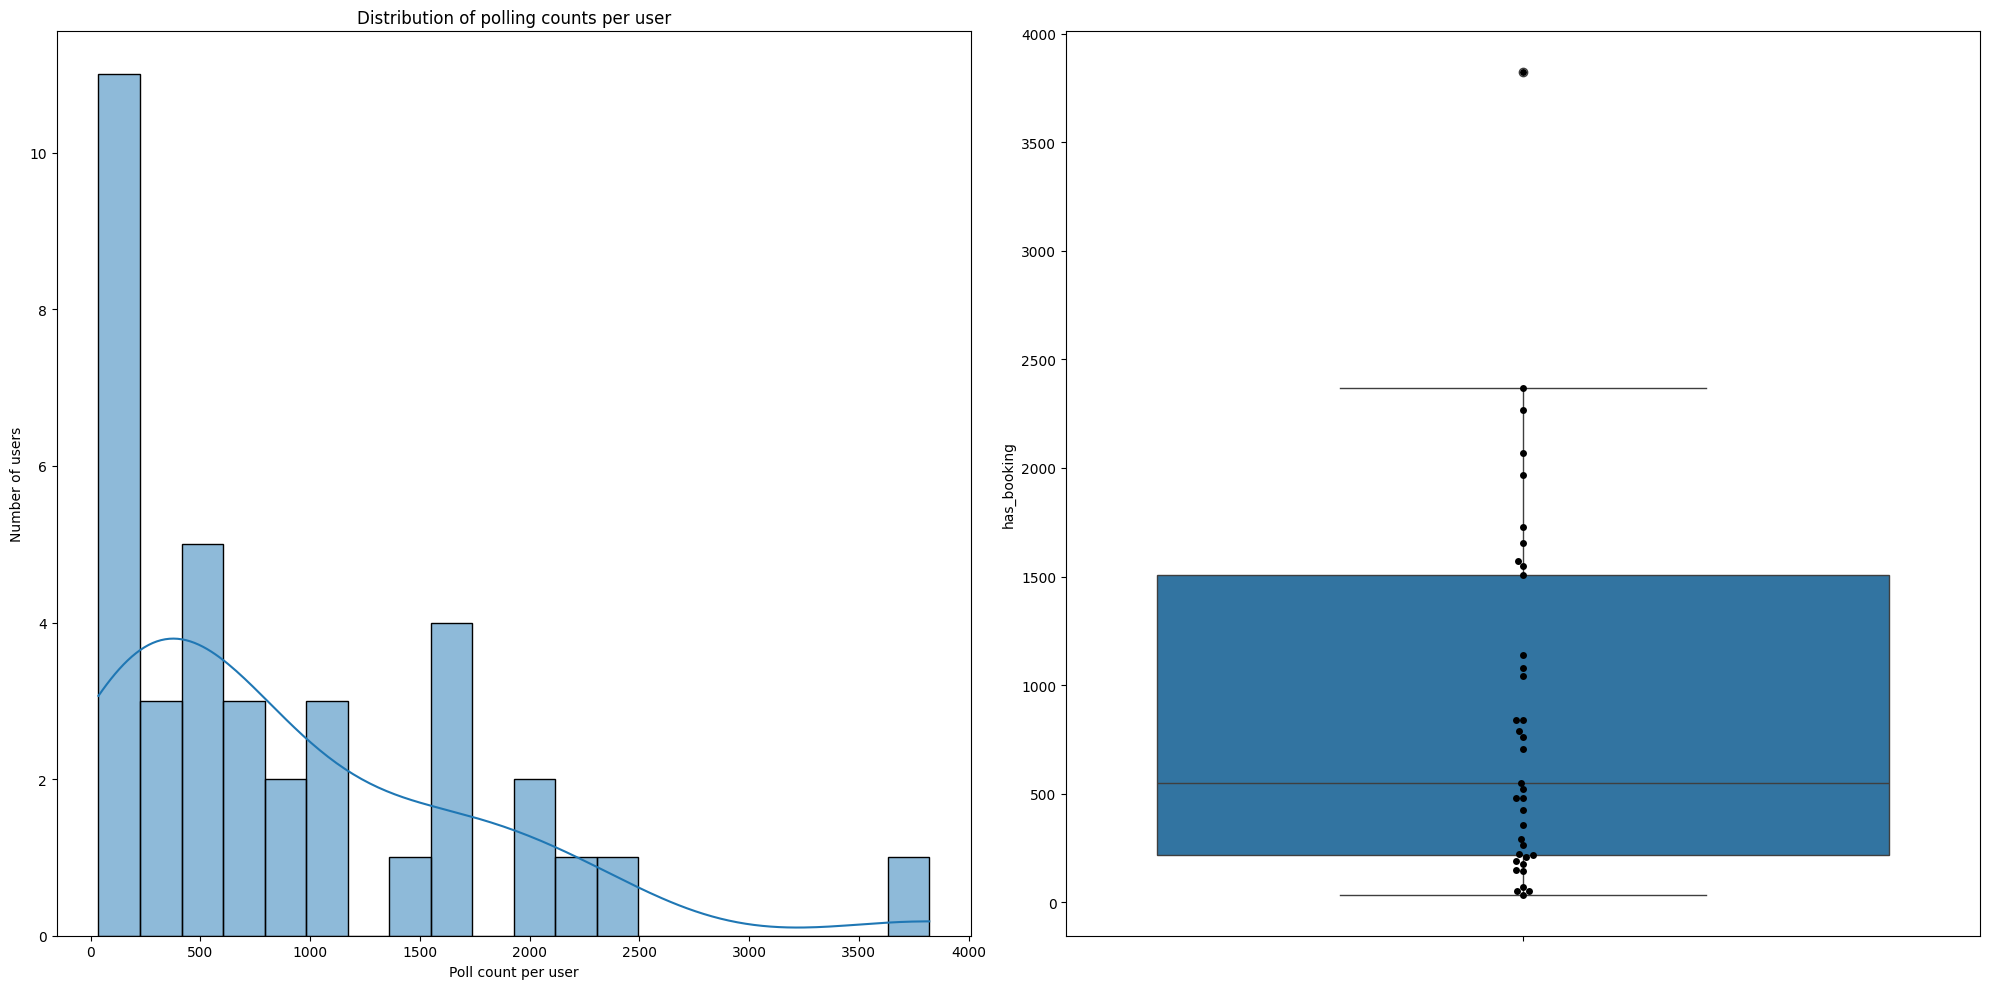

In [269]:
user_distribution = df.groupby("username")["has_booking"].count().sort_values().reset_index()
print(user_distribution.tail())

fig, axes = plt.subplots(1,2,figsize=(20, 10))
sns.histplot(
    data=user_distribution,
    x="has_booking",
    bins=20,
    kde=True,      
    ax=axes[0]
)
axes[0].set_xlabel("Poll count per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of polling counts per user")

sns.boxplot(data=user_distribution,y="has_booking",ax=axes[1])
sns.swarmplot(data=user_distribution,y="has_booking",color="black",ax=axes[1])
plt.tight_layout()
plt.show()

In [270]:
count = df.groupby(["username"])["has_booking"].count().reset_index()
q_25,q_50,q_75 = count["has_booking"].quantile([0.25,0.5,0.75])

iqr = q_75 - q_25
print(q_25,q_50,q_75,iqr)

217.0 552.0 1507.0 1290.0


<Axes: xlabel='poll_count', ylabel='booking_rate'>

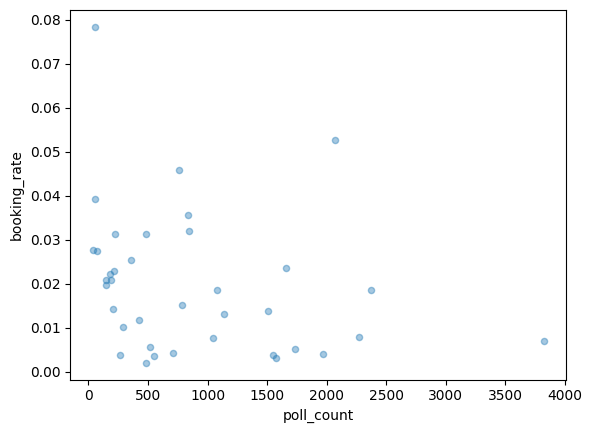

In [271]:
stats = df.groupby("username")["has_booking"].agg(["count", "mean"]).reset_index()
stats.columns = ["username", "poll_count", "booking_rate"]

# Does booking rate correlate with how long they've been observed?
stats.plot.scatter(x="poll_count", y="booking_rate", alpha=0.4)

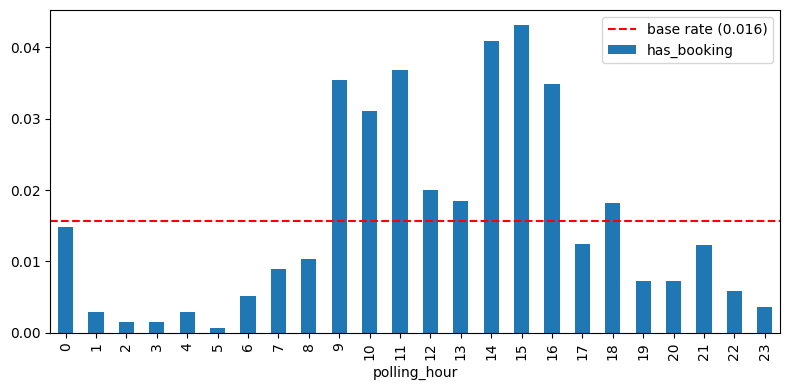

In [272]:
def success_share(x):
    rate = df.groupby(x)["has_booking"].mean()
    base = df["has_booking"].mean()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    rate.plot(kind="bar", ax=ax)
    ax.axhline(base, color="red", linestyle="--", label=f"base rate ({base:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

success_share("polling_hour")


   username  count     share
0       kim   3821  0.117176
1        jy   2369  0.072649
2    flower   2268  0.069551
3     anmol   2067  0.063387
4      ryan   1967  0.060321
5     anaya   1730  0.053053
6       mya   1656  0.050784
7      matt   1574  0.048269
8       ali   1550  0.047533
9      srpr   1507  0.046214
10    faith   1141  0.034990
11   tomato   1079  0.033089
12  brendon   1044  0.032016
13      joy    842  0.025821
14      jun    840  0.025760
15    apple    787  0.024134
16   poopie    762  0.023368
17  gohguan    706  0.021650
18    natar    552  0.016928
19      fir    521  0.015977
20       bw    481  0.014751
21   addity    480  0.014720
22       np    425  0.013033
23    bryan    355  0.010887
24  lucinda    294  0.009016
25        d    264  0.008096
26   aswath    224  0.006869
27      nur    217  0.006655
28     phuc    209  0.006409
29    carol    192  0.005888
30     sara    179  0.005489
31  pakning    151  0.004631
32    bhara    144  0.004416
33    isyaf   

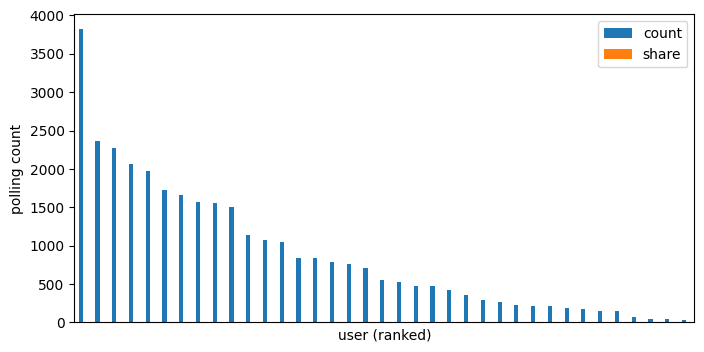

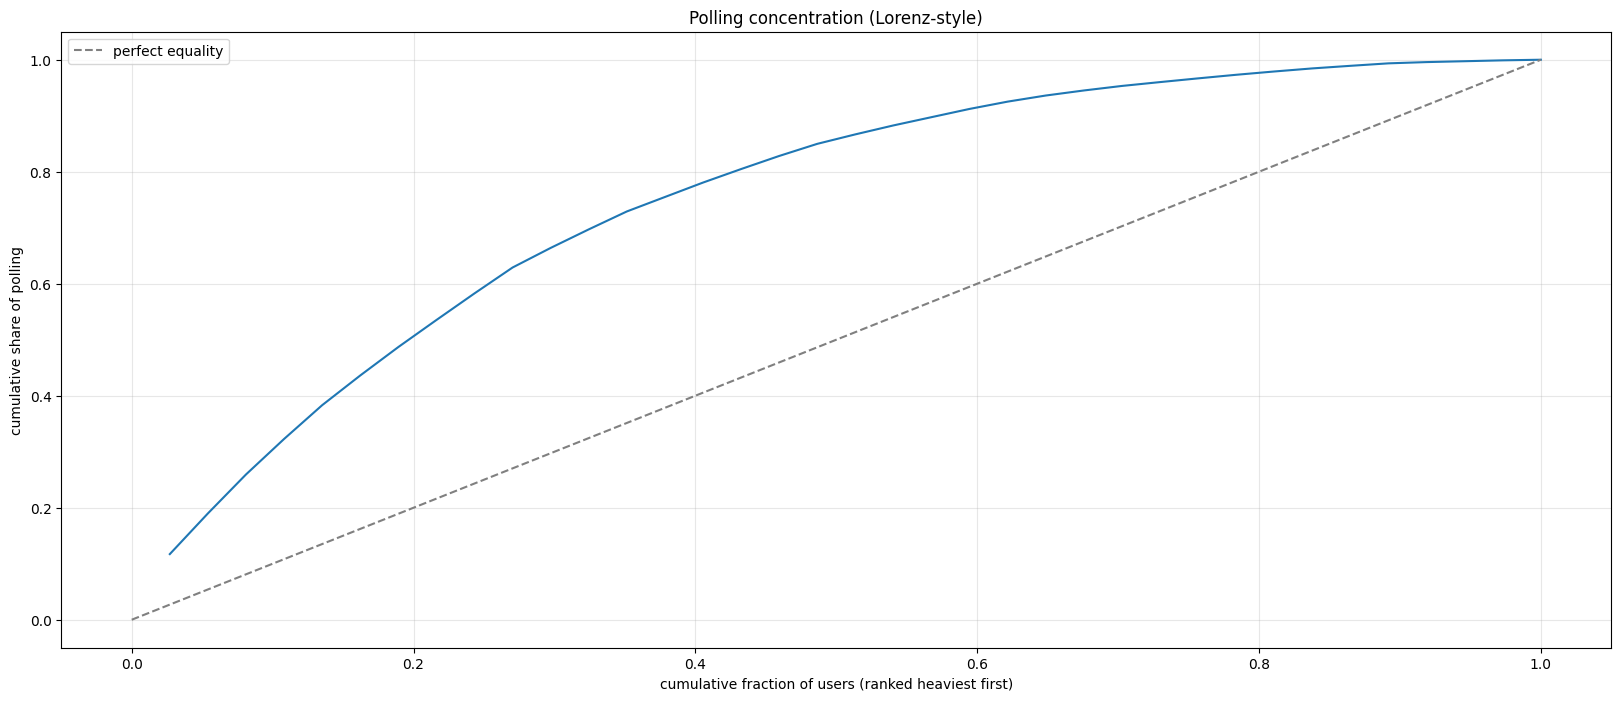

In [273]:
counts = df['username'].value_counts().reset_index().assign(share=lambda x:x["count"]/len(df))
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax)
ax.set_ylabel('polling count')
ax.set_xlabel('user (ranked)')
ax.set_xticks([])  # hide labels if there are many users


counts_sorted = (
    counts.sort_values('share', ascending=False)
          .reset_index(drop=True)
)
counts_sorted['cum_share'] = counts_sorted['share'].cumsum()
counts_sorted['cum_user_frac'] = (counts_sorted.index + 1) / len(counts_sorted)

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(counts_sorted['cum_user_frac'], counts_sorted['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')

In [274]:
import numpy as np

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

print(f'Gini: {gini(counts["share"].values):.3f}')

Gini: 0.498


top 5% of users (1) → 11.7% of polls
top 10% of users (3) → 25.9% of polls
top 20% of users (7) → 48.7% of polls
top 50% of users (18) → 85.0% of polls


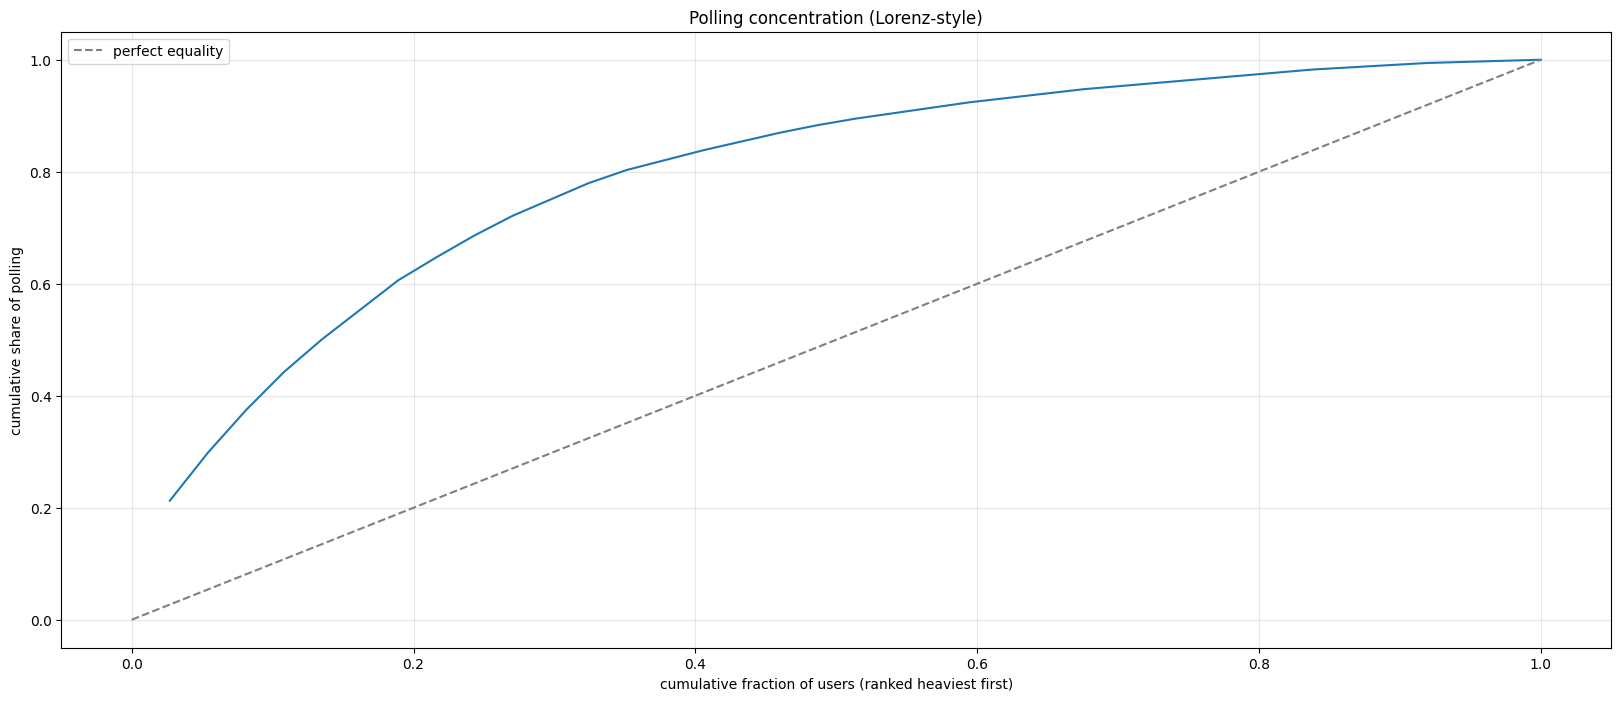

In [275]:
total_sum = df["has_booking"].sum()
whales_sum = df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False).reset_index(name="sum")
whales_sum["share"] = whales_sum["sum"]/total_sum


whales_sum["cum_share"] = whales_sum["share"].cumsum()
whales_sum["cum_frac"] = ((whales_sum.index +1) / len(whales_sum))


fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(whales_sum['cum_frac'], whales_sum['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')


In [276]:
whales_count = counts_sorted.iloc[:int(0.10*len(whales_sum))]
print(whales_count)

  username  count     share  cum_share  cum_user_frac
0      kim   3821  0.117176   0.117176       0.027027
1       jy   2369  0.072649   0.189825       0.054054
2   flower   2268  0.069551   0.259376       0.081081


In [277]:
whales_positive_share = whales_sum.iloc[:int(0.10*len(whales_sum))]
print(whales_positive_share)

  username  sum     share  cum_share  cum_frac
0    anmol  109  0.212476   0.212476  0.027027
1       jy   44  0.085770   0.298246  0.054054
2      mya   39  0.076023   0.374269  0.081081


JS divergence (positive-location): 0.276   # 0 = identical pattern, 1 = disjoint


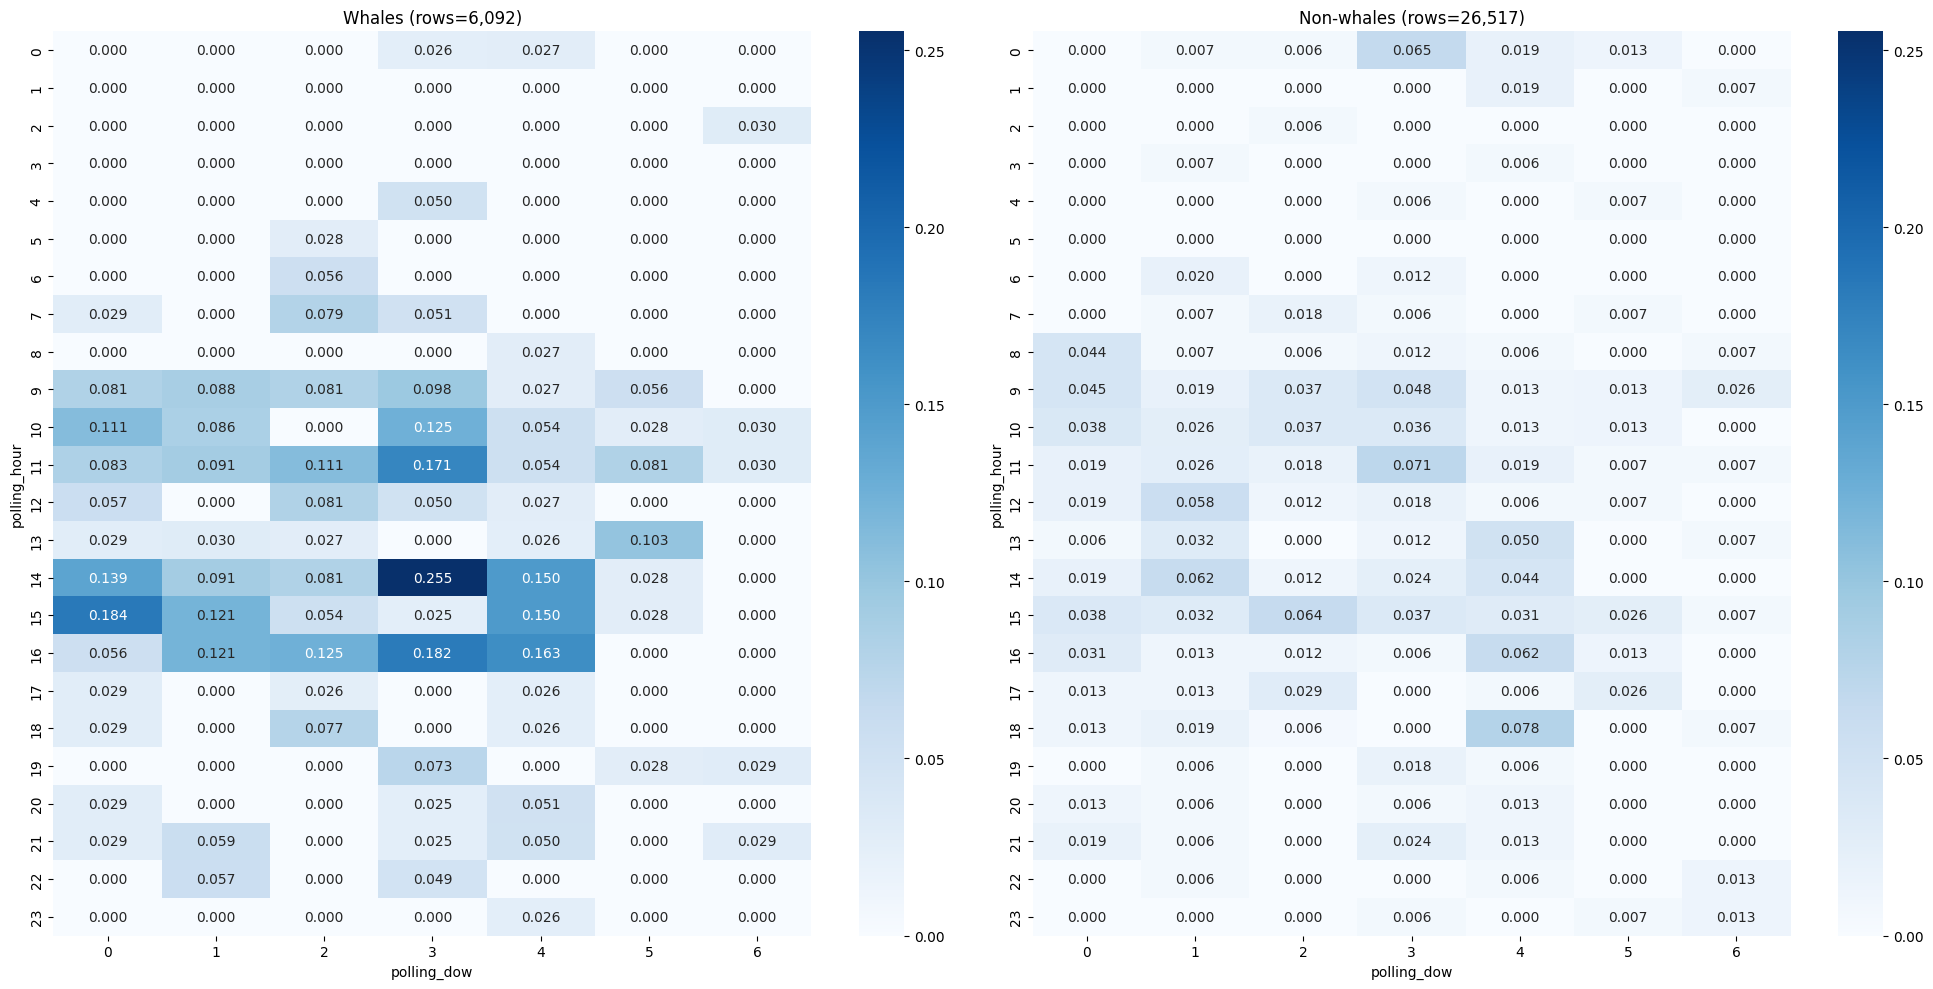

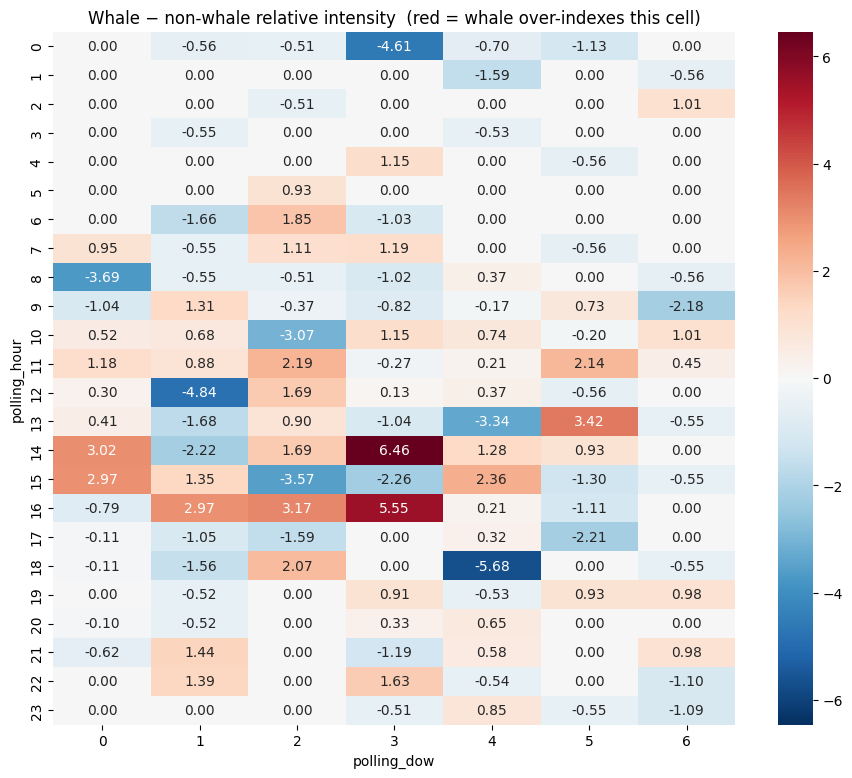

In [280]:
import numpy as np

whales = ["anmol", "jy", "mya"]
is_whale = df["username"].isin(whales)

# Full grid so BOTH heatmaps share identical axes (missing cells -> NaN, not dropped/misaligned)
dows  = sorted(df["polling_dow"].unique())
hours = sorted(df["polling_hour"].unique())

def grid(sub):
    g = sub.groupby(["polling_dow", "polling_hour"])["has_booking"]
    rate    = g.mean().unstack("polling_dow").reindex(index=hours, columns=dows)
    support = g.size().unstack("polling_dow").reindex(index=hours, columns=dows)
    return rate, support

w_rate,  w_support  = grid(df[is_whale])
nw_rate, nw_support = grid(df[~is_whale])

# Mask cells with too few polls to trust the rate (whale side is only 3 users)
MIN_POLLS = 30
w_rate_m  = w_rate.mask(w_support  < MIN_POLLS)
nw_rate_m = nw_rate.mask(nw_support < MIN_POLLS)

# --- FIX 1: shared color scale, so the side-by-side is honest about LEVEL ---
vmax = float(np.nanmax([np.nanmax(w_rate_m.values), np.nanmax(nw_rate_m.values)]))
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(w_rate_m,  annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[0])
sns.heatmap(nw_rate_m, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[1])
axes[0].set_title(f"Whales (rows={int(is_whale.sum()):,})")
axes[1].set_title(f"Non-whales (rows={int((~is_whale).sum()):,})")
plt.tight_layout()

# --- FIX 2: shape-only difference map, to separate "books more" from "books at different times" ---
w_shape  = w_rate_m  / np.nanmean(w_rate_m.values)     # relative intensity, own mean = 1.0
nw_shape = nw_rate_m / np.nanmean(nw_rate_m.values)
diff = w_shape - nw_shape
fig2, ax2 = plt.subplots(figsize=(11, 9))
lim = float(np.nanmax(np.abs(diff.values)))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax2)
ax2.set_title("Whale − non-whale relative intensity  (red = whale over-indexes this cell)")

# --- FIX 3: one number instead of an eyeball — JS divergence of WHERE positives land ---
def booking_dist(sub):  # distribution of positives across cells, counts-based (no support mask needed)
    c = (sub.groupby(["polling_dow","polling_hour"])["has_booking"].sum()
            .unstack("polling_dow").reindex(index=hours, columns=dows).fillna(0).values.ravel())
    return c / c.sum()

p, q = booking_dist(df[is_whale]), booking_dist(df[~is_whale])
m = 0.5 * (p + q)
kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
print(f"JS divergence (positive-location): {js:.3f}   # 0 = identical pattern, 1 = disjoint")

<Axes: xlabel='hours_into_cycle', ylabel='Count'>

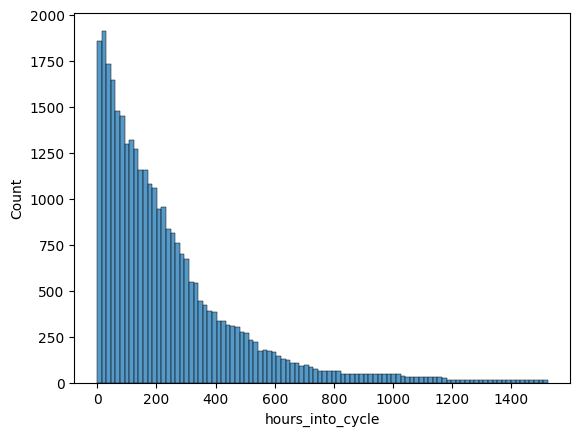

In [ ]:
sns.histplot(data=df,x="hours_into_cycle")

    is_one_team             hours_bin  has_booking
0             0     (-2.474, 151.468]     0.016838
1             0    (151.468, 303.887]     0.017803
2             0    (303.887, 456.305]     0.016047
3             0    (456.305, 608.723]     0.029281
4             0    (608.723, 761.142]     0.010370
5             0     (761.142, 913.56]     0.023364
6             0    (913.56, 1065.978]     0.000000
7             0  (1065.978, 1218.397]     0.027273
8             1     (-2.474, 151.468]     0.019930
9             1    (151.468, 303.887]     0.006481
10            1    (303.887, 456.305]     0.007060
11            1    (456.305, 608.723]     0.007962
12            1    (608.723, 761.142]     0.000000
13            1     (761.142, 913.56]     0.000000
14            1    (913.56, 1065.978]     0.000000
15            1  (1065.978, 1218.397]     0.013072
16            1  (1218.397, 1370.815]     0.000000
17            1  (1370.815, 1523.233]     0.000000
    is_one_team             hou

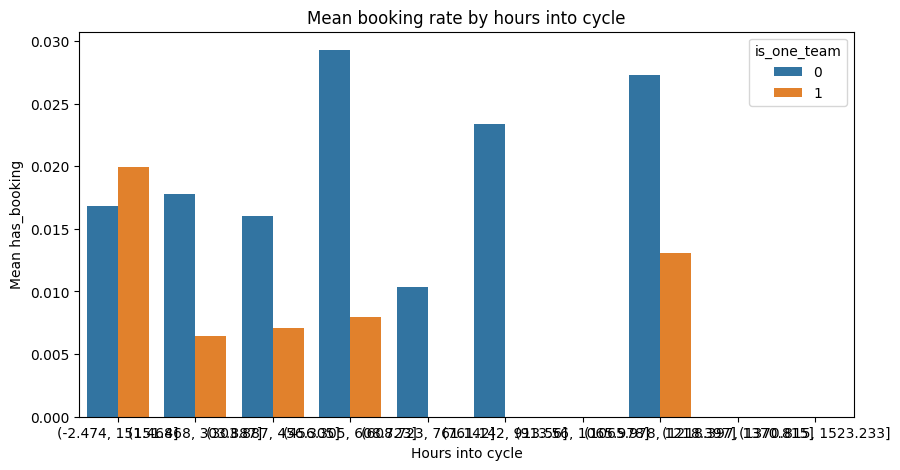

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_bin = pd.cut(df["hours_into_cycle"],bins=10)
df = df.assign(hours_bin=hour_bin)
hours_into_share = df.groupby(['is_one_team',"hours_bin"])["has_booking"].mean().reset_index()
print(hours_into_share)

print(hours_into_share)
plt.figure(figsize=(10,5))
sns.barplot(data=hours_into_share,x="hours_bin", y="has_booking",hue="is_one_team")
plt.xlabel("Hours into cycle")
plt.ylabel("Mean has_booking")
plt.title("Mean booking rate by hours into cycle")
plt.show()

In [ ]:
one_team_count = df["is_one_team"].value_counts(normalize=True)
print(one_team_count)



is_one_team
0    0.680763
1    0.319237
Name: proportion, dtype: float64


In [ ]:
team_count= df.groupby(["is_one_team"])["has_booking"].mean()
print(team_count)


is_one_team
0    0.017704
1    0.011527
Name: has_booking, dtype: float64


In [ ]:
class_count = df["class_type"].value_counts(normalize=True)
print(class_count)

class_type
1    0.638167
0    0.361833
Name: proportion, dtype: float64


In [ ]:
class_count= df.groupby(["class_type"])["has_booking"].mean()
print(class_count)

class_type
0    0.011526
1    0.018116
Name: has_booking, dtype: float64


In [ ]:
customer = df.drop_duplicates(["username"])[["is_one_team"]].value_counts()
print(customer)

is_one_team
0              26
1              11
Name: count, dtype: int64


In [ ]:
heatmap = df.groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()

In [ ]:
heatmap

,polling_dow,polling_hour,has_booking
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.000000
3,0,3,0.000000
4,0,4,0.000000
...,...,...,...
163,6,19,0.005348
164,6,20,0.000000
165,6,21,0.005348
166,6,22,0.010695


In [ ]:
pv = pd.pivot(data=heatmap,index="polling_hour",columns="polling_dow",values="has_booking")

<Axes: xlabel='polling_dow', ylabel='polling_hour'>

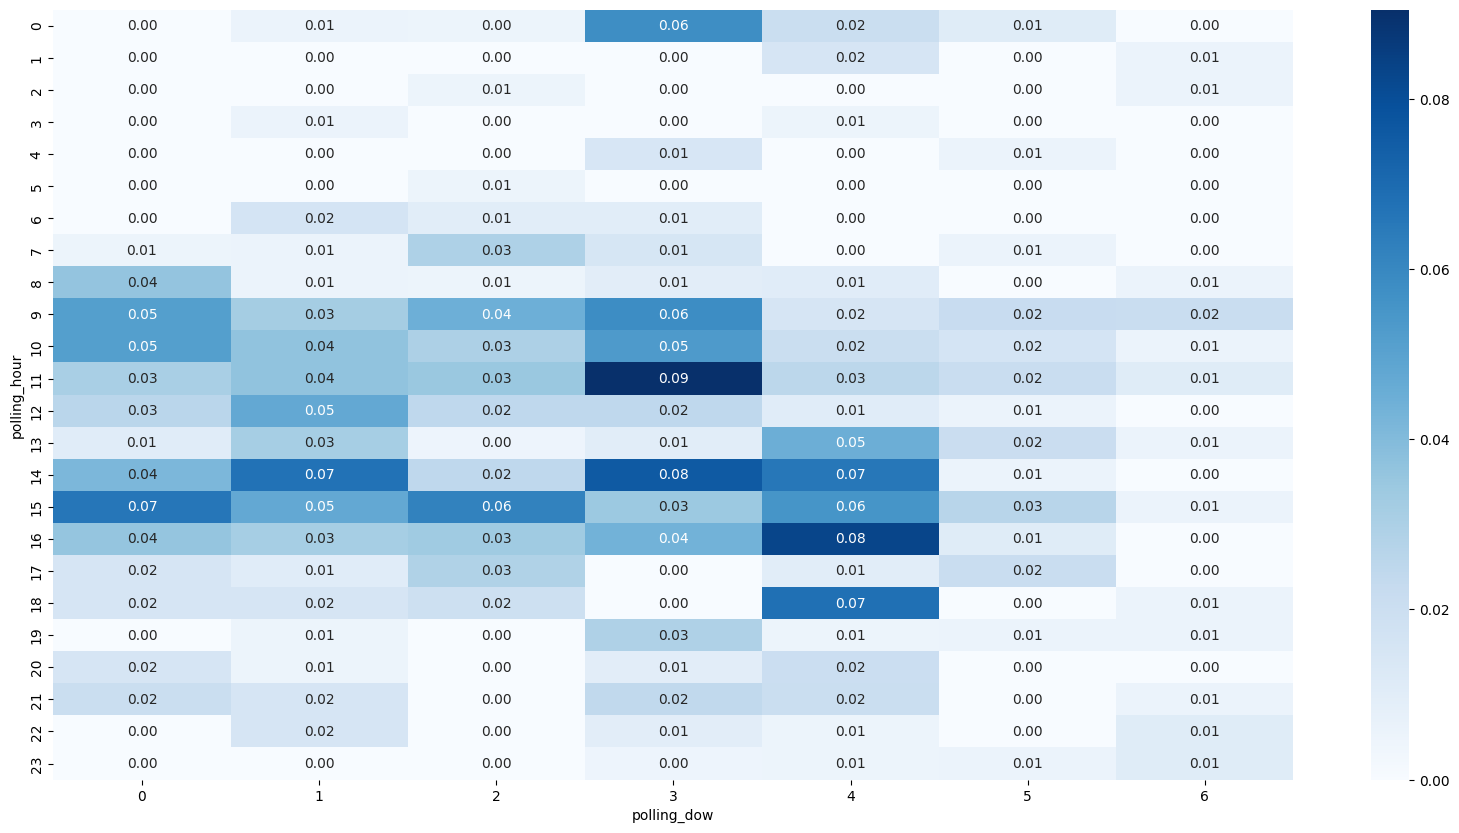

In [ ]:
fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(pv,annot=True,fmt=".2f",cmap="Blues")

      username               cycle_start                 cycle_end  \
0       addity 2025-08-13 21:00:00+08:00 2025-08-28 11:36:00+08:00   
22934     matt 2025-08-12 01:21:00+08:00 2025-09-23 23:52:00+08:00   
23862      max 2025-09-24 00:00:00+08:00 2025-09-25 23:59:00+08:00   
25540    natar 2025-10-16 00:00:00+08:00 2025-10-17 23:59:00+08:00   
23877      mya 2025-10-29 16:15:00+08:00 2025-11-01 23:59:00+08:00   
27877     ryan 2025-11-01 21:30:00+08:00 2025-11-03 23:59:00+08:00   
31570   tomato 2025-11-26 11:00:00+08:00 2025-11-27 23:59:00+08:00   
26900     phuc 2025-12-30 16:00:00+08:00 2026-01-01 23:59:00+08:00   
26869  pakning 2026-01-20 17:00:00+08:00 2026-01-26 23:59:00+08:00   
996        ali 2026-02-06 10:00:00+08:00 2026-02-25 23:59:00+08:00   
9538     faith 2026-02-27 00:00:00+08:00 2026-03-09 23:59:00+08:00   

       cycle_duration  
0          350.600000  
22934     1030.516667  
23862       47.983333  
25540       47.983333  
23877       79.733333  
27877       50.

<Axes: ylabel='cycle_duration'>

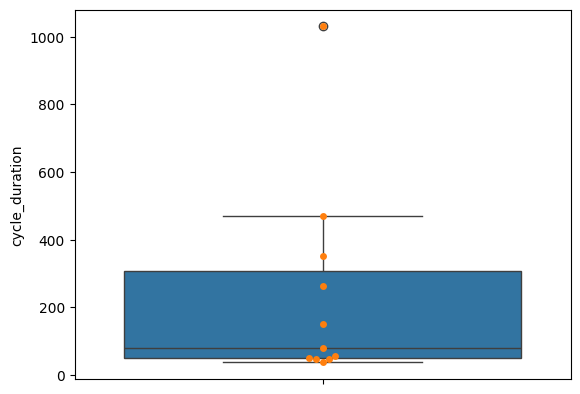

In [ ]:
ot_customers = df.loc[df["is_one_team"]==1].sort_values("cycle_end").drop_duplicates(subset=["username"],keep="first")[["username","cycle_start","cycle_end"]]
ot_customers["cycle_duration"] = (ot_customers["cycle_end"] - ot_customers["cycle_start"]).dt.total_seconds()/3600
print(ot_customers)
sns.boxplot(data=ot_customers,y="cycle_duration")
sns.swarmplot(data=ot_customers,y="cycle_duration")

Overall base rate: 0.0157


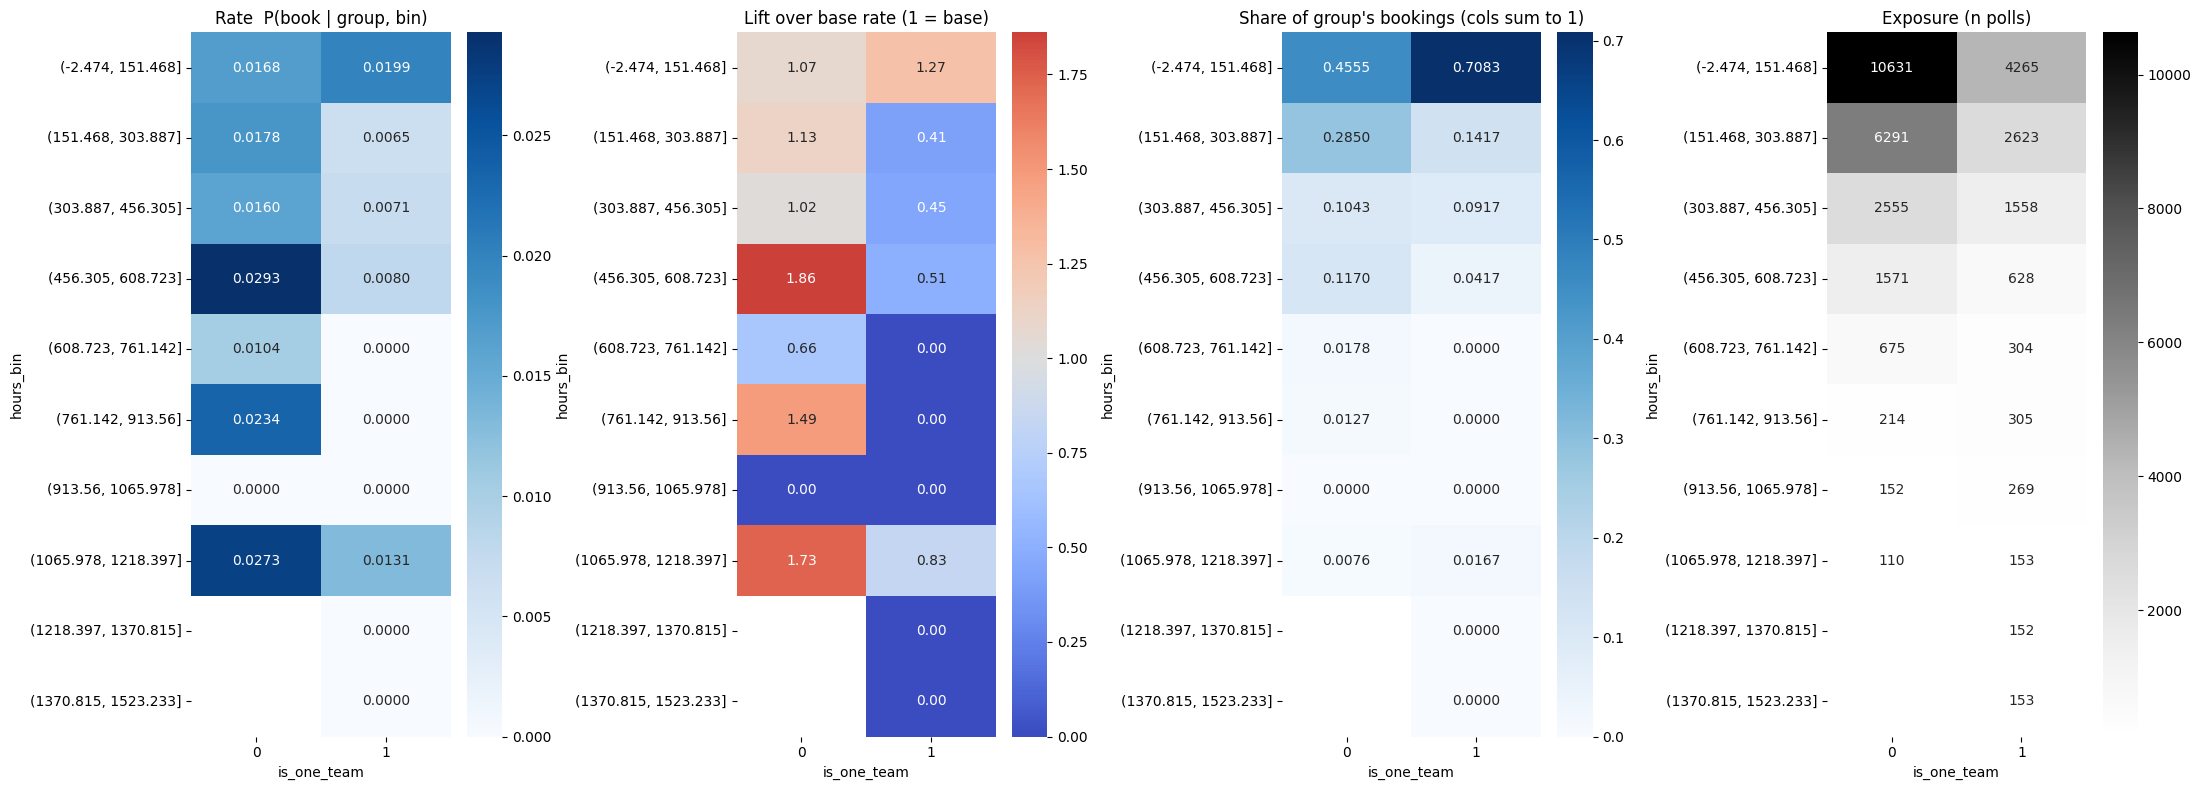

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

base_rate = df["has_booking"].mean()
print(f"Overall base rate: {base_rate:.4f}")

# one pass, all aggregates
g = (df.groupby(["is_one_team", "hours_bin"])["has_booking"]
       .agg(n_polls="count", n_bookings="sum", rate="mean")
       .reset_index())

# within-group totals for normalization
grp_bookings = df.groupby("is_one_team")["has_booking"].sum()

# share of THIS GROUP's bookings landing in this bin -> columns sum to ~1 -> tests concentration
g["share_of_group_bookings"] = g["n_bookings"] / g["is_one_team"].map(grp_bookings)
# multiplicative lift over base rate -> reads signal strength, not absolute smallness
g["lift"] = g["rate"] / base_rate

def pv(col):
    return pd.pivot(g, index="hours_bin", columns="is_one_team", values=col)

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

sns.heatmap(pv("rate"), annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("Rate  P(book | group, bin)")

sns.heatmap(pv("lift"), annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title("Lift over base rate (1 = base)")

sns.heatmap(pv("share_of_group_bookings"), annot=True, fmt=".4f", cmap="Blues", ax=axes[2])
axes[2].set_title("Share of group's bookings (cols sum to 1)")

sns.heatmap(pv("n_polls"), annot=True, fmt=".0f", cmap="Greys", ax=axes[3])
axes[3].set_title("Exposure (n polls)")

plt.tight_layout()
plt.show()